In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules

import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

from pathlib import Path

In [2]:
mode = "FULL_2D" # "RADIAL_ONLY" or "FULL_2D"
solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, mode)

In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j


In [3]:
# mesh_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Meshes")
mesh_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Meshes")
mesh_save_dir.mkdir(parents=True, exist_ok=True)

# figure_save_dir = Path("/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/Figures")
figure_save_dir = Path("/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Figures")
figure_save_dir.mkdir(parents=True, exist_ok=True)


solver.build_physics_Stix_B_field()
mesh = solver.build_mesh_with_PMLs()
# print('num_vertices = ', mesh.nv)

GF_E_field, _, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode, )

Lx_pml = 1.000e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 2.58e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 2.21e-05, h_min_pml_corner: 1.68e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURRED IN 1 FACES:

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
#DoFs = 4066436 (= number of mesh points).


used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.46e-01, computed at z=2.001e-01m
  --> Toroidal Gamma_T: 2.95e-01, computed at x=1.415e-02m
  --> Net Power Flow (W/m) | In: 1.3023e-01 | Top: 2.9253e-02 | Right: 9.9836e-02 | Left: -1.0525e-03


In [4]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260608_155859
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260608_155859


--- Extracting 2D Wave Map ---
[run 2D E map]
Lx_plasma: 2.00e-02m, Lx_pml: 1.00e-02m, Lx_tot: 3.00e-02m
Lz_plasma: 2.03e-01m, Lz_pml: 4.05e-02m, Lz_tot: 2.84e-01m
params recover in run_2D_wave_map
  --> Safely interpolating FEM fields onto structured grid...
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
PP_run_n_save: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260608_155859/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui
key: x_target_R, type(key): <class 'str'>, val: 0.019
key: peak_z_R, type(key): <class 'str'>, val: 0.20013942704116278
key: window_size_radial, type(key): <class 'str'>, val: 0.013531183537789516
key: z_target_T, type(key): <class 'str'>, val: 0.19243434804054055
key: peak_x_T, type(key): <class 'str'>, val: 0.014149549549549553
key: window_size_toroidal, type(key): <class 'str'>, val

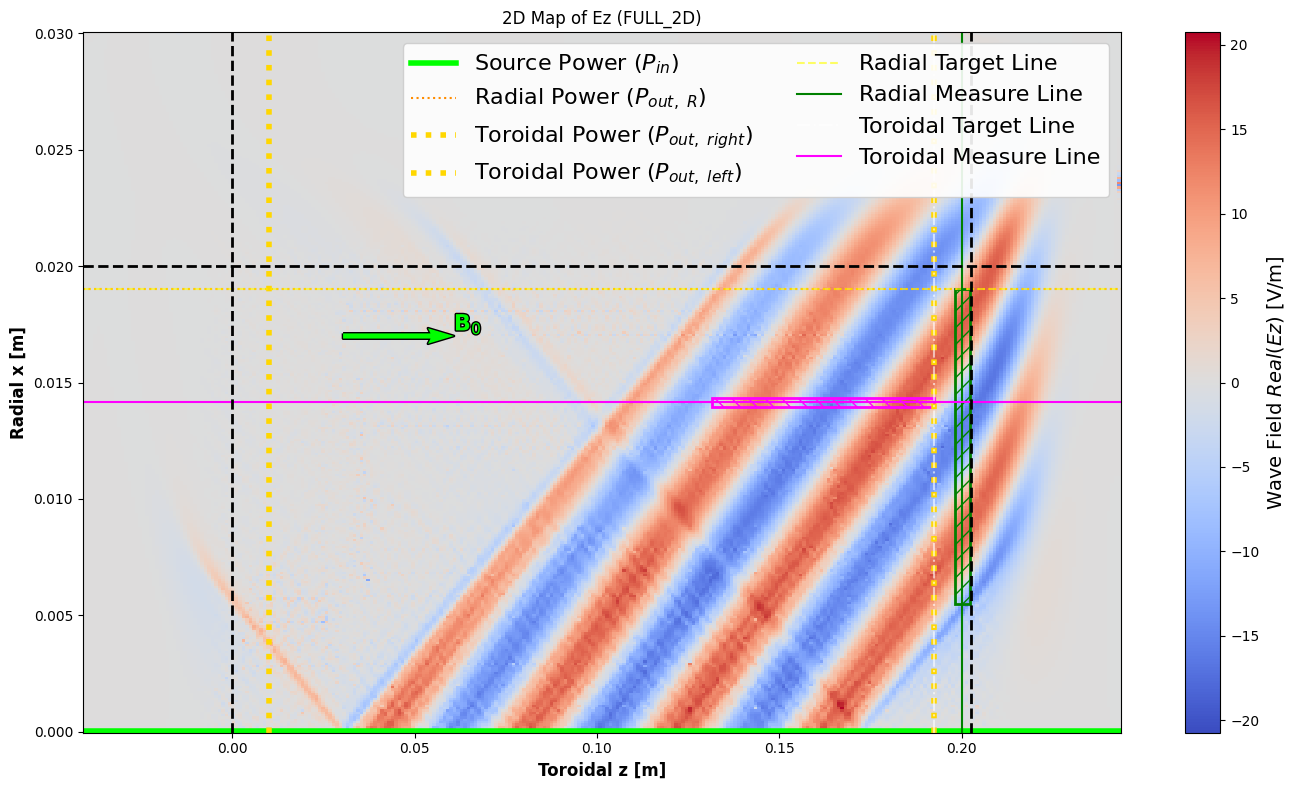

In [5]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, mode, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, mode, component='Ez', value_type='real', plot_poynting=False, show_windows=True, Poynting_box=True)

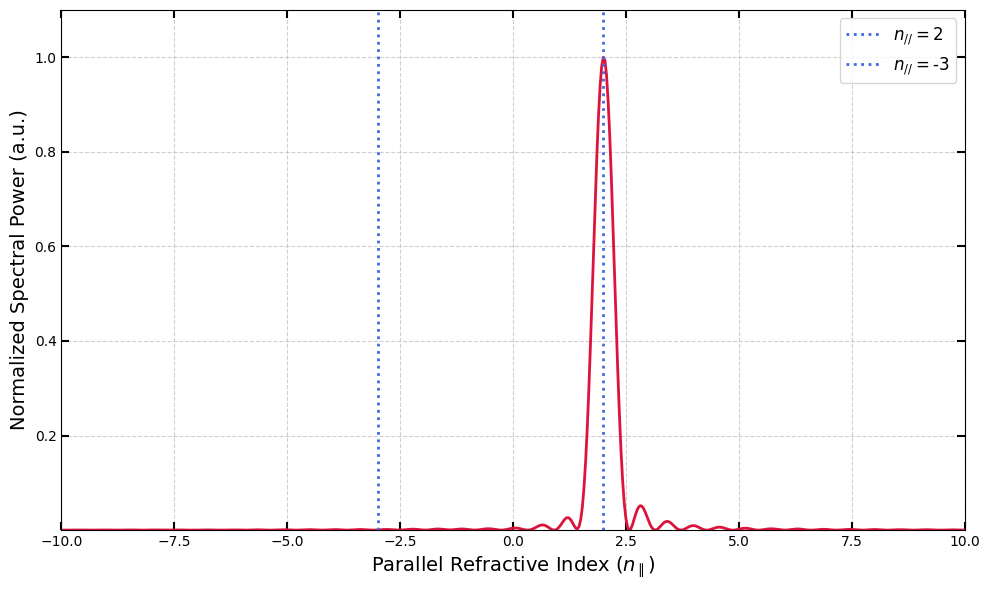

In [6]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, mode, x_eval=0.001)


  STARTING 2D TOROIDAL & RADIAL PML SENSITIVITY SCAN

---> Scanning Group: Depth Ratio (Lx_pml_ratio & Lz_pml_ratio)
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 4.510e-03m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 2.58e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 2.21e-05, h_min_pml_corner: 1.68e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURRED IN 1 FACES:

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
#DoFs 

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.84e-01, computed at z=1.960e-01m
  --> Toroidal Gamma_T: 2.35e-01, computed at x=1.415e-02m
  --> Net Power Flow (W/m) | In: 1.2975e-01 | Top: 2.9517e-02 | Right: 9.9039e-02 | Left: -9.6705e-04
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 6.766e-03m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 2.58e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 2.21e-05, h_min_pml_corner: 1.68e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURR

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.51e-01, computed at z=1.995e-01m
  --> Toroidal Gamma_T: 3.24e-01, computed at x=1.415e-02m
  --> Net Power Flow (W/m) | In: 1.2998e-01 | Top: 2.7611e-02 | Right: 1.0115e-01 | Left: -1.0538e-03
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 9.021e-03m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 2.58e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 2.21e-05, h_min_pml_corner: 1.68e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURR

...

kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.97e-01, computed at z=1.960e-01m
  --> Toroidal Gamma_T: 3.23e-01, computed at x=1.415e-02m
  --> Net Power Flow (W/m) | In: 1.2994e-01 | Top: 2.8811e-02 | Right: 9.9845e-02 | Left: -1.1541e-03
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 3.383e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 2.58e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 2.21e-05, h_min_pml_corner: 1.68e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURR

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.37e-01, computed at z=2.005e-01m
  --> Toroidal Gamma_T: 3.26e-01, computed at x=1.415e-02m
  --> Net Power Flow (W/m) | In: 1.3013e-01 | Top: 2.8822e-02 | Right: 9.9740e-02 | Left: -1.4845e-03
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 3.608e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:5.00e+00, h_min_pml_radial: 2.58e-05
Sz_norm_max: 5.83e+00, h_min_pml_toroidal: 2.21e-05, h_min_pml_corner: 1.68e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURR

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.06e-01, computed at z=2.001e-01m
  --> Toroidal Gamma_T: 2.27e-01, computed at x=1.315e-02m
  --> Net Power Flow (W/m) | In: 1.3020e-01 | Top: 3.0561e-02 | Right: 9.7794e-02 | Left: -1.8105e-03


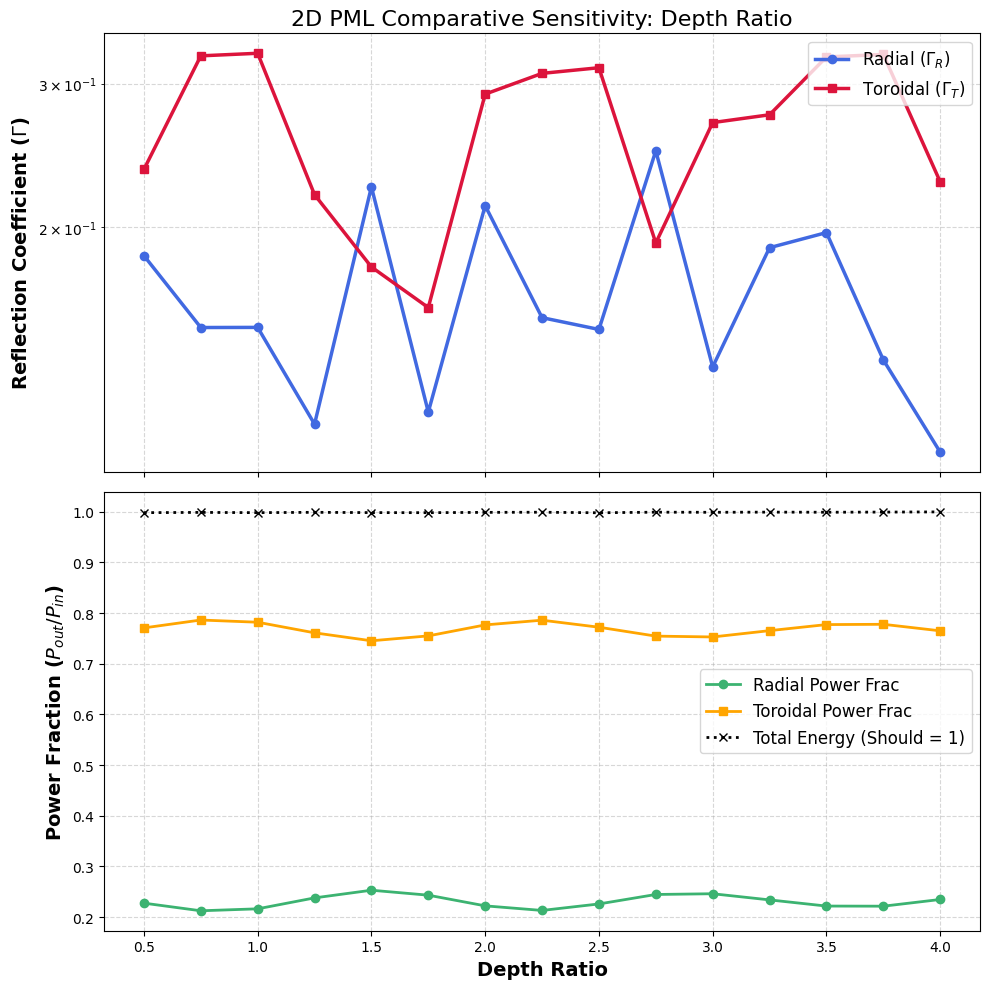


---> Scanning Group: Imaginary Damping (Sx_im & Sz_im)
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 1.000e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:3.04e+00, h_min_pml_radial: 4.24e-05
Sz_norm_max: 3.04e+00, h_min_pml_toroidal: 4.24e-05, h_min_pml_corner: 3.00e-05

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_plasma resolution : 1.12760e-03 m
#DoFs = 2275230 (= number of mesh points).
kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.93e-01, computed at z=1.964e-01m
  --> Toroidal Gamma_T: 4.37e-01, computed at x=1.609e-02m
  --> Net Power Flow (W/m) | In: 1.3013e-01 | Top: 3.0540e-02 | Right: 9.8368e-02 | Left: -1.01

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 1.89e-01, computed at z=1.958e-01m
  --> Toroidal Gamma_T: 3.29e-01, computed at x=1.415e-02m
  --> Net Power Flow (W/m) | In: 1.3033e-01 | Top: 2.9305e-02 | Right: 9.9794e-02 | Left: -1.0715e-03
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 1.000e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:5.61e+00, h_min_pml_radial: 2.30e-05
Sz_norm_max: 5.61e+00, h_min_pml_toroidal: 2.30e-05, h_min_pml_corner: 1.63e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURRED IN 1 FACES:

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 2.26e-01, computed at z=1.958e-01m
  --> Toroidal Gamma_T: 2.39e-01, computed at x=1.315e-02m
  --> Net Power Flow (W/m) | In: 1.3033e-01 | Top: 2.9773e-02 | Right: 9.9331e-02 | Left: -1.1125e-03
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 1.000e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:6.13e+00, h_min_pml_radial: 2.10e-05
Sz_norm_max: 6.13e+00, h_min_pml_toroidal: 2.10e-05, h_min_pml_corner: 1.49e-05
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURRED IN 1 FACES:

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max_

...

kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 5.11e-01, computed at z=2.026e-03m
  --> Toroidal Gamma_T: 8.18e-01, computed at x=1.980e-02m
  --> Net Power Flow (W/m) | In: 1.2551e-01 | Top: -5.0770e+01 | Right: 2.5060e-01 | Left: -4.2887e+02
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 1.000e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:1.06e+01, h_min_pml_radial: 1.21e-05
Sz_norm_max: 1.06e+01, h_min_pml_toroidal: 1.21e-05, h_min_pml_corner: 8.58e-06
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURRED IN 1 FACES:

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---
window_size_radial: 1.3531e-02 m, window_size_toroidal: 6.0769e-02 m
  --> Radial Gamma_R: 6.27e-01, computed at z=2.026e-03m
  --> Toroidal Gamma_T: 7.33e-01, computed at x=1.980e-02m
  --> Net Power Flow (W/m) | In: 1.1905e-01 | Top: -1.2181e+02 | Right: 2.4299e-01 | Left: -8.9948e+02
In LHCoupling class: n_para: 2.0, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Lx_pml = 1.000e-02m
Lz_plasma = 2.03e-01m, Lz_pml = 4.05e-02m
lambda_para = 4.05e-02m
h_max_plasma: 1.13e-03
[Build Mesh:]
PPW_pml: 70.0, Sx_norm_max:1.12e+01, h_min_pml_radial: 1.15e-05
Sz_norm_max: 1.12e+01, h_min_pml_toroidal: 1.15e-05, h_min_pml_corner: 8.14e-06
 ERROR: Problem in Surface mesh generation
WARNING! NOT ALL FACES HAVE BEEN MESHED
SURFACE MESHING ERROR OCCURRED IN 1 FACES:

[MESH BUILDER - FULL_2D] :
  --> SW n_perp_p : 8.98203e+00+0.00000e+00j, n_perp_m = 0.00000e+00+1.62548e+00j
  --> Effective meshing index used : 8.98203e+00
  --> h_max

used dof inconsistency
(silence this warning by setting BilinearForm(...check_unused=False) )


kz:1.55e+02
--- Solving the 3D vector linear system ---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import gc
from ngsolve import *
from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

def run_2D_pml_comparative_scan(base_cfg, scan_groups):
    print("=====================================================")
    print("  STARTING 2D TOROIDAL & RADIAL PML SENSITIVITY SCAN")
    print("=====================================================")
    
    results = {}

    for group_name, (param_values, param_x, param_z) in scan_groups.items():
        print(f"\n---> Scanning Group: {group_name} ({param_x} & {param_z})")
        gamma_R_array, gamma_T_array = [], []
        P_R_frac, P_T_frac = [], []
        
        for val in param_values:
            # 1. Safely Deep Copy the baseline config
            scan_cfg = {}
            for key, value in base_cfg.items():
                if isinstance(value, dict) and not key.startswith('__'):
                    scan_cfg[key] = copy.deepcopy(value)
            
            # 2. Inject BOTH parameters simultaneously
            for param_name in [param_x, param_z]:
                if param_name in ['Sx_r', 'Sz_r', 'Sx_im', 'Sz_im', 'px', 'pz']:
                    scan_cfg['PML'][param_name] = val
                elif param_name in ['Lx_pml_ratio', 'Lz_pml_ratio']:
                    c0, freq = scan_cfg['CONST']['c0'], scan_cfg['WAVE']['freq_LH']
                    lambda0 = c0 / freq
                    temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="FULL_2D")
                    n_para, n_perp_p, _ = temp_solver.compute_physics_parameters()
                    del temp_solver
                    
                    if param_name == 'Lx_pml_ratio':
                        scan_cfg['DOMAIN']['Lx_pml'] = val * (lambda0 / np.abs(n_perp_p.real))
                        scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + scan_cfg['DOMAIN']['Lx_pml']
                    elif param_name == 'Lz_pml_ratio':
                        scan_cfg['DOMAIN']['Lz_pml'] = val * (lambda0 / np.abs(n_para))
                        scan_cfg['DOMAIN']['Lz_tot'] = scan_cfg['DOMAIN']['Lz_plasma'] + 2 * scan_cfg['DOMAIN']['Lz_pml']
                elif param_name == 'ppw_pml':
                    scan_cfg['PML']['ppw_pml'] = val

            # 3. Initialize and Run the 2D Physics Solver
            solver, mesh, gfu = None, None, None
            Gamma_R, Gamma_T = 1.0, 1.0 
            frac_R, frac_T = 0.0, 0.0
            
            try:
                solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, mode="FULL_2D")
                solver.build_physics_Stix_B_field()
                mesh = solver.build_mesh_with_PMLs()
                
                gfu, _, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, mode="FULL_2D")
                
                # Compute Power Fractions safely
                P_in_net = max(abs(diag_data['P_in_net']), 1e-15)
                frac_R = diag_data['P_out_R'] / P_in_net
                
                # Add positive power flowing to top, and subtract negative power flowing out bottom
                net_toroidal_power = diag_data['P_out_T_right'] - diag_data['P_out_T_left']
                frac_T = net_toroidal_power / P_in_net
                power_inj_efficiency = diag_data['P_in_net'] / diag_data['P_ideal']
                print(f'Power injection efficiency: {power_inj_efficiency:.4e}')
                print(f'P_inc*(1-Gamma_R)**2: {diag_data['P_ideal'] * (1-Gamma_R**2)}')
                print(f'P_inc*(1-Gamma_T)**2: {diag_data['P_ideal'] * (1-Gamma_T**2)}')

            except Exception as e:
                print(f"  [Val = {val:.4e}] -> SOLVER FAILED: {e}")
                
            finally:
                gamma_R_array.append(Gamma_R)
                gamma_T_array.append(Gamma_T)
                P_R_frac.append(frac_R)
                P_T_frac.append(frac_T)
                
                if mesh is not None: del mesh
                if gfu is not None: del gfu
                if solver is not None: del solver
                gc.collect()

        results[group_name] = (param_values, gamma_R_array, gamma_T_array)
        
        # 4. Generate Comparative Two-Panel Plot
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
        
        # Plot 1: Gamma Coefficients
        ax1.plot(param_values, gamma_R_array, marker='o', color='royalblue', lw=2.5, label=rf'Radial ($\Gamma_R$)')
        ax1.plot(param_values, gamma_T_array, marker='s', color='crimson', lw=2.5, label=rf'Toroidal ($\Gamma_T$)')
        ax1.set_yscale('log')
        ax1.grid(True, which='both', linestyle='--', alpha=0.5)
        ax1.set_ylabel(r"Reflection Coefficient ($\Gamma$)", fontsize=14, fontweight='bold')
        ax1.set_title(f"2D PML Comparative Sensitivity: {group_name}", fontsize=16)
        ax1.legend(loc='upper right', fontsize=12)
        
        # Plot 2: Power Fractions (Energy Conservation)
        total_frac = np.array(P_R_frac) + np.array(P_T_frac)
        ax2.plot(param_values, P_R_frac, marker='o', color='mediumseagreen', lw=2, label='Radial Power Frac')
        ax2.plot(param_values, P_T_frac, marker='s', color='orange', lw=2, label='Toroidal Power Frac')
        ax2.plot(param_values, total_frac, marker='x', color='black', lw=2, linestyle=':', label='Total Energy (Should = 1)')
        
        ax2.grid(True, linestyle='--', alpha=0.5)
        xlabel_str = group_name
        ax2.set_xlabel(xlabel_str, fontsize=14, fontweight='bold')
        ax2.set_ylabel(r"Power Fraction ($P_{out} / P_{in}$)", fontsize=14, fontweight='bold')
        ax2.legend(loc='center right', fontsize=12)
        
        plt.tight_layout()
        plt.show()

    return results

# EXECUTION 
scans_to_run_2D = {
    'Depth Ratio': (np.linspace(0.5, 4.0, 15), 'Lx_pml_ratio', 'Lz_pml_ratio'),
    'Imaginary Damping': (np.linspace(0.5, 12.0, 20), 'Sx_im', 'Sz_im'),
    'Polynomial Smoothing': (np.linspace(1.0, 4.0, 15), 'px', 'pz')
}
scan_results_2D = run_2D_pml_comparative_scan(cfg.__dict__, scans_to_run_2D)